## Generation of Protein Vector Given a 2D Sequence

Import Packages:

In [75]:
import numpy as np

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
import optuna
import re

from typing import Union

import matplotlib.pyplot as plt

import transformers
from transformers import AutoTokenizer, AutoModel


import requests

import esm

from tscales_bert_cls import TScalesBERTEncoder, encode_tscales_cls

import pytorch_lightning as pl

from pytorch_lightning.loggers import WandbLogger



Load the dataset:

In [76]:
df = pd.read_csv("Datasets/Fluorescent-Protein-Database.csv")

Generate t-scale for protein sequences:

In [77]:
encoder = TScalesBERTEncoder(d_model=256, nhead=8, num_layers=4)
tscales_cls = encode_tscales_cls(df["Protein sequence"], encoder)
df["tscales_cls"] = list(tscales_cls)

c:\Users\Adrian\Documents\Studium\M1\ai\AI-for-Chemistry-Project\tscales_bert_cls.py:84: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer,


Using Evolutionary Scale Modeling (ESM-2) Embeddings

In [78]:
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()


In [79]:
def get_esm_embedding(seq):
    data = [("protein", seq)]

    _, _, tokens = batch_converter(data)

    with torch.no_grad():
        results = model(tokens, repr_layers=[33])

    # layer 33 = final representation
    reps = results["representations"][33]

    # remove special tokens and mean pool
    embedding = reps[0, 1:-1].mean(0)

    return embedding.numpy()


df["esm"] = df["Protein sequence"].apply(get_esm_embedding)

Encode SMILES of chromophores using pre-trained chemBERTa RNN

In [80]:
#assignment of canonical SMILES of ligand
smiles_dict = {
    "NRQ": r"CSCCC(=N)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "CRQ": r"NC(=O)CCC(=N)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "NRP": r"CC(C)CC(=N)C1=NC(=C/c2ccc(O)cc2)/C(=O)N1CC(O)=O",
    "CH6": r"CSCC[C@H](N)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "CRO": r"[C@@H](O)[C@H](N)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "5SQ": r"N[C@@H](Cc1c[nH]cn1)C2=NC(=C\c3ccc(O)cc3)/C(=O)N2CC(O)=O",
    "4M9": r"NC(=O)CCC(=N)C1=NC(=C\c2c[nH]c3ccccc23)/C(=O)N1CC(O)=O",
    "CR2": r"NCC1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "OFM": r"C[C@H]1O[C@@](O)(N=C1C2=N\C(=C/c3ccc(O)cc3)C(=O)N2CC(O)=O)[C@@H](N)Cc4ccccc4",
    "CR8": r"N[C@@H](Cc1[nH]cnc1)c2nc(C=C3C=CC(=O)C=C3)c([O-])n2CC(O)=O",
    "CFY": r"N[C@@H](Cc1ccccc1)[C@@]2(O)SCC(=N2)C3=NC(=C\c4ccc(O)cc4)/C(=O)N3CC(O)=O",
    "OIM": r"CC[C@H](C)[C@H](N)[C@@]1(O)O[C@H](C)C(=N1)C2=N\C(=C/c3ccc(O)cc3)C(=O)N2CC(O)=O",
    "CH7": r"OC(=O)CN1C(=O)C(=C/c2ccc(O)cc2)/N=C1C3=NCCCC3",
    "GYS": r"N[C@@H](CO)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "WCR": r"C[C@@]1(O)NC(=C\c2ccc(O)cc2)/C(=O)N1CC(O)=O",
    "DYG": r"N[C@@H](CC(O)=O)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "FAD": r"Cc1cc2N=C3C(=O)NC(=O)N=C3N(C[C@H](O)[C@H](O)[C@H](O)CO[P@](O)(=O)O[P@@](O)(=O)OC[C@H]4O[C@H]([C@H](O)[C@@H]4O)n5cnc6c(N)ncnc56)c2cc1C",
    "PIA": r"C[C@H](N)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "BLR": r"CC1=C(C=C)C(/NC1=O)=C/c2[nH]c(Cc3[nH]c(\C=C4/NC(=O)C(=C4C)C=C)c(C)c3CCC(O)=O)c(CCC(O)=O)c2C",
    "CRF": r"C[C@@H](O)[C@H](N)C1=N\C(=C/c2c[nH]c3ccccc23)C(=O)N1CC(O)=O",
    "NYG": r"N[C@@H](CC(N)=O)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "FMN": r"Cc1cc2N=C3C(=O)NC(=O)N=C3N(C[C@H](O)[C@H](O)[C@H](O)CO[P](O)(O)=O)c2cc1C",
    "B2H": r"C[C@@H](O)[C@H](N)c1nc(Cc2c[nH]c3ccccc23)c(O)n1CC(O)=O",
    "SWG": r"N[C@@H](CO)C1=N\C(=C/c2c[nH]c3ccccc23)C(=O)N1CC(O)=O",
    "CSH": r"N[C@@H](CO)[C@H]1N[C@@H](Cc2c[nH]cn2)C(=O)N1CC(O)=O",
    "BJF": r"CC(C)C[C@H](N)c1nc(CC(C)C)c(O)n1CC(O)=O",
    "GYC": r"N[C@@H](CS)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O",
    "CCY": r"N[C@@H](CS)[C@H]1N[C@@H](Cc2ccc(O)cc2)C(=O)N1CC(O)=O",
    "CR7": r"NCCCC[C@H](N)C1=N\C(=C/c2ccc(O)cc2)C(=O)N1CC(O)=O"
}   
df["smiles"] = df["Chromophore/ligand"].str.strip().str.upper().map(smiles_dict)
from transformers import AutoTokenizer, AutoModel


model_name = "seyonec/ChemBERTa-zinc-base-v1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

def smiles_to_vector(smiles):
    if not isinstance(smiles, str):
        return None

    inputs = tokenizer(smiles, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token embedding = molecular representation
    pooled = outputs.last_hidden_state.max(dim=1).values.squeeze()

    return pooled.numpy()


df["smiles_vectors"] = df["smiles"].apply(smiles_to_vector)



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 24074.30it/s]
[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Concatenation of sequence vectors obtained with ESM, ligand SMILES vectors obtained with chemBERTa, and predictor values (Stokes shift, EC, quantum yield, protein mass) 

In [81]:

def concat_model1(row):
    return np.concatenate([
        row["esm"],                    # 1280-d
        row["smiles_vectors"],         # 768-d
        np.array([
            row["Stokes shift"],      
            row["kDa"]
        ])
    ])



def concat_model2(row):
    return np.concatenate([
        row["tscales_cls"],            # 256-d
        row["smiles_vectors"],         # 768-d
        np.array([
            row["Stokes shift"],       
            row["kDa"]
        ])
    ])



At this point, the dataset is split in train, validation and test data. For each subset, input and target data is normalized using StandardScaler.

In [82]:

scaler = StandardScaler()
num_cols = ["Stokes shift", "kDa", "Emission wavelength", "Brightness"]
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.3, random_state=42)
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
val_df[num_cols] = scaler.transform(val_df[num_cols])
test_df[num_cols]  = scaler.transform(test_df[num_cols])



Beyond concatenation, the future X and Y inputs to the NN must be brought into shape digestible to NN. N.b.: from this point on data in no longer stored in df, as it makes variation of shape more managable.

In [84]:
train_df["X_train_esm"] = train_df.apply(concat_model1, axis=1)
val_df["X_val_esm"] = val_df.apply(concat_model1, axis=1)
test_df["X_test_esm"]  = test_df.apply(concat_model1, axis=1)

train_df["X_train_tscale"] = train_df.apply(concat_model2, axis=1)
val_df["X_val_tscale"] = val_df.apply(concat_model2, axis=1)
test_df["X_test_tscale"]  = test_df.apply(concat_model2, axis=1)

esm_train_stacked = np.stack(train_df["X_train_esm"].values).astype(np.float32)
esm_val_stacked = np.stack(val_df["X_val_esm"].values).astype(np.float32)
esm_test_stacked = np.stack(test_df["X_test_esm"].values).astype(np.float32)
tscales_train_stacked = np.stack(train_df["X_train_tscale"].values).astype(np.float32)
tscales_val_stacked = np.stack(val_df["X_val_tscale"].values).astype(np.float32)
tscales_test_stacked = np.stack(test_df["X_test_tscale"].values).astype(np.float32)
Emission_wavelength_train_float = train_df["Emission wavelength"].values.astype(np.float32)
Emission_wavelength_val_float = val_df["Emission wavelength"].values.astype(np.float32)
Emission_wavelength_test_float = test_df["Emission wavelength"].values.astype(np.float32)
Brightness_train_float = train_df["Brightness"].values.astype(np.float32)
Brightness_val_float = val_df["Brightness"].values.astype(np.float32)
Brightness_test_float = test_df["Brightness"].values.astype(np.float32)
target_train = np.stack(
    [Emission_wavelength_train_float, Brightness_train_float],
    axis=1
).astype(np.float32)
target_val = np.stack(
    [Emission_wavelength_val_float, Brightness_val_float],
    axis=1
).astype(np.float32)
target_test = np.stack(
    [Emission_wavelength_test_float, Brightness_test_float],
    axis=1
).astype(np.float32)


Input: X input will be concatenation of sequence vector, SMILES vector, stokes shift and molecular weight. Y input will be emission wavelenght.

In [86]:

X_train_esm = esm_train_stacked
X_val_esm = esm_val_stacked
X_test_esm = esm_test_stacked  

X_train_tscales = tscales_train_stacked
X_val_tscales = tscales_val_stacked 
X_test_tscales = tscales_test_stacked 

Y_train_esm = target_train
Y_val_es = target_val
Y_test_esm = target_test

Y_train_tscales = target_train
Y_val_tscales = target_val
Y_test_tscales = target_test

Using PyTorch, a Neural Network class is defined:

In [101]:
class NeuralNetwork(pl.LightningModule):
    def __init__(self, input_sz, hidden_sz, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()  # saves input_size, hidden_size, lr

        self.layer_1 = torch.nn.Linear(input_sz, hidden_sz)
        self.layer_2 = torch.nn.Linear(hidden_sz, hidden_sz)
        self.layer_3 = torch.nn.Linear(hidden_sz, 2)

    def forward(self, x):
        x = self.layer_1(x)
        x = F.relu(x)
        x = self.layer_2(x)
        x = F.relu(x)
        x = self.layer_3(x)
        return x
    
    def _shared_step(self, batch):
        x, y = batch
        preds = self(x)
        loss = F.mse_loss(preds, y)
        return loss
        
    def training_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("train_loss", loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("val_loss", loss, prog_bar=True)
    
        
    def test_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("test_MSE", loss)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.lr
        )
        return optimizer

The Dataset class is defined as well:

In [94]:
from torch.utils.data import Dataset

class FPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
esm_train_data = FPDataset(X_train_esm, Y_train_esm)
tscales_train_data = FPDataset(X_train_tscales, Y_train_tscales)
esm_val_data = FPDataset(X_val_esm, Y_val_es)
tscales_val_data = FPDataset(X_val_tscales, Y_val_tscales)
esm_test_data = FPDataset(X_train_esm, Y_train_esm)
tscales_test_data = FPDataset(X_train_tscales, Y_train_tscales)

Afin de tracer loss et MSE en fonction du no. d'Epochs, une class callback est definie ci-dessous:

In [89]:
class MetricsCallback(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.val_mse = []

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if "train_loss" in metrics:
            self.train_loss.append(metrics["train_loss"].item())

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if "val_loss" in metrics:
            self.val_loss.append(metrics["val_loss"].item())
        if "val_mse" in metrics:
            self.val_mse.append(metrics["val_mse"].item())

Next, the datamodule is defined: 

In [90]:
class NeuralNetworkDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, val_dataset, test_dataset, batch_size=256):
        super().__init__()
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.batch_size = batch_size

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)
    
    def val_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)    

Finally, the model is trained. Using optuna, optimization of hyperparameters takes place automatically. First, the esm-encoded input is used:

In [95]:
import logging
import os
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ["PL_DISABLE_PROGRESS_BAR"] = "1"
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
#6 previous lines silence redundant output messages upon training
def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 128, 1024)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    
   

    data_module_esm = NeuralNetworkDataModule(
    train_dataset=esm_train_data,
    val_dataset=esm_val_data,
    test_dataset=esm_test_data,
    batch_size = batch_size
    )

    
    model = NeuralNetwork(
        input_sz=X_train_esm.shape[1],
        hidden_sz=hidden_size,
        lr=lr
    )

    trainer = pl.Trainer(
        max_epochs=20,  
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False
    )

    
    trainer.fit(model, datamodule=data_module_esm)

    val_loss = trainer.callback_metrics["val_loss"].item()

    return val_loss

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best_params_esm:", study.best_params)
best_params_esm = study.best_params



c:\Users\Adrian\Documents\Studium\M1\ai\AI-for-Chemistry-Project\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Best_params_esm: {'hidden_size': 542, 'lr': 0.0002872157566230932, 'batch_size': 128}


The model is retrained with the optimized parameteres:

┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer_1 │ Linear │  1.1 M │ train │     0 │
│ 1 │ layer_2 │ Linear │  294 K │ train │     0 │
│ 2 │ layer_3 │ Linear │  1.1 K │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\Adrian\Documents\Studium\M1\ai\AI-for-Chemistry-Project\.venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\Adrian\Documents\Studium\M1\ai\AI-for-Chemistry-Project\.venv\Lib\site-packages\pytorch_lightning\loops\fi
t_loop.py:317: The number of training batches (1) is smaller than the logging interval 
Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training 
epoch.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MSE          │    0.4113556444644928     │
└───────────────────────────┴───────────────────────────┘

c:\Users\Adrian\Documents\Studium\M1\ai\AI-for-Chemistry-Project\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MSE          │    0.4113556444644928     │
└───────────────────────────┴───────────────────────────┘

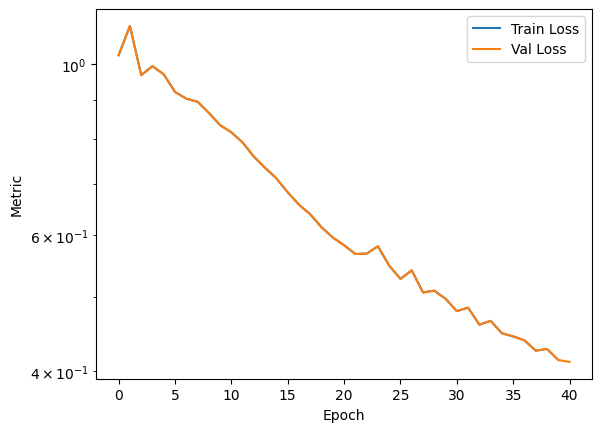

In [96]:
Best_params_esm = best_params_esm
hidden_size = best_params_esm["hidden_size"]
lr = best_params_esm["lr"]
batch_size = best_params_esm["batch_size"]

metrics_callback = MetricsCallback()

data_module_esm = NeuralNetworkDataModule(
    train_dataset=esm_train_data,
    val_dataset=esm_val_data,
    test_dataset=esm_test_data,
    batch_size=batch_size
)
model_esm = NeuralNetwork(
    input_sz=X_train_esm.shape[1],
    hidden_sz=hidden_size,
    lr=lr
)
trainer = pl.Trainer(
    max_epochs=40,  
    logger=True,
    enable_checkpointing=True,
    callbacks = metrics_callback
)

trainer.fit(model_esm, datamodule=data_module_esm)
trainer.test(model_esm, datamodule=data_module_esm)
results_tscale = trainer.test(model_esm, datamodule=data_module_esm, ckpt_path="best")
plt.plot(metrics_callback.train_loss, label="Train Loss")
plt.plot(metrics_callback.val_loss, label="Val Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.show()


Now, the same is done using the tscale data. Again, optimal hyperparameters are determined first:

In [97]:
import logging
import os
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ["PL_DISABLE_PROGRESS_BAR"] = "1"
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
#6 previous lines silence redundant output messages upon training
def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 128, 1024)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    
   

    data_module_tscales = NeuralNetworkDataModule(
    train_dataset=tscales_train_data,
    val_dataset=tscales_val_data,
    test_dataset=tscales_test_data,
    batch_size = batch_size
    )

    
    model = NeuralNetwork(
        input_sz=1026,
        hidden_sz=hidden_size,
        lr=lr
    )

    trainer = pl.Trainer(
        max_epochs=20,  
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False
    )

    
    trainer.fit(model, datamodule=data_module_tscales)

    val_loss = trainer.callback_metrics["val_loss"].item()

    return val_loss

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best_params_tscales:", study.best_params)
best_params_tscales = study.best_params



┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer_1 │ Linear │  503 K │ train │     0 │
│ 1 │ layer_2 │ Linear │  240 K │ train │     0 │
│ 2 │ layer_3 │ Linear │    982 │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

Trainable params: 744 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 744 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer_1 │ Linear │  324 K │ train │     0 │
│ 1 │ layer_2 │ Linear │  100 K │ train │     0 │
│ 2 │ layer_3 │ Linear │    634 │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

Trainable params: 425 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 425 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer_1 │ Linear │  724 K │ train │     0 │
│ 1 │ layer_2 │ Linear │  497 K │ train │     0 │
│ 2 │ layer_3 │ Linear │  1.4 K │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

...

┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer_1 │ Linear │  1.0 M │ train │     0 │
│ 1 │ layer_2 │ Linear │  1.0 M │ train │     0 │
│ 2 │ layer_3 │ Linear │  2.0 K │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer_1 │ Linear │  1.0 M │ train │     0 │
│ 1 │ layer_2 │ Linear │  1.0 M │ train │     0 │
│ 2 │ layer_3 │ Linear │  2.0 K │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Best_params_tscales: {'hidden_size': 1019, 'lr': 0.00015112139289491183, 'batch_size': 128}


Again, best parameters are used for actual training_

┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer_1 │ Linear │  1.0 M │ train │     0 │
│ 1 │ layer_2 │ Linear │  1.0 M │ train │     0 │
│ 2 │ layer_3 │ Linear │  2.0 K │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MSE          │    0.20834806561470032    │
└───────────────────────────┴───────────────────────────┘

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MSE          │    0.20834806561470032    │
└───────────────────────────┴───────────────────────────┘

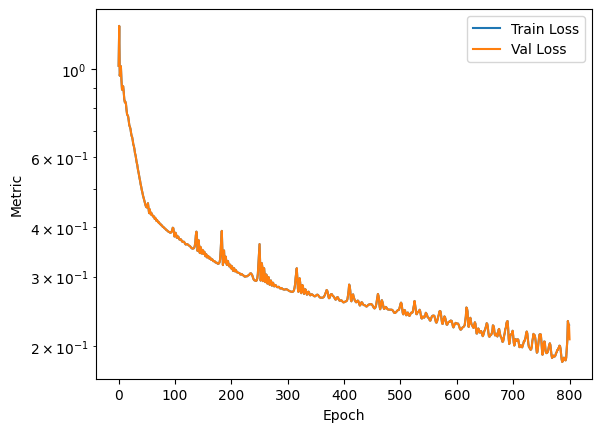

In [ ]:
Best_params_tscales = best_params_tscales
hidden_size = best_params_tscales["hidden_size"]
lr = best_params_tscales["lr"]
batch_size = best_params_tscales["batch_size"]

metrics_callback = MetricsCallback()

data_module_tscales = NeuralNetworkDataModule(
    train_dataset=tscales_train_data,
    val_dataset=tscales_val_data,
    test_dataset=tscales_test_data,
    batch_size=batch_size
)
model_tscales = NeuralNetwork(
    input_sz=X_train_tscales.shape[1],
    hidden_sz=hidden_size,
    lr=lr
)
trainer = pl.Trainer(
    max_epochs=100,  
    logger=True,
    enable_checkpointing=True,
    callbacks = [metrics_callback]
)

trainer.fit(model_tscales, datamodule=data_module_tscales)
trainer.test(model_tscales, datamodule=data_module_tscales)
results_tscale = trainer.test(model_tscales, datamodule=data_module_tscales, ckpt_path="best")
plt.plot(metrics_callback.train_loss, label="Train Loss")
plt.plot(metrics_callback.val_loss, label="Val Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.show()
